# 1. Business Understanding

### 1.1 Contexto do negócio

O Palavritas é um jogo diário do the news cujo sucesso depende da recorrência de uso. O objetivo desta análise é identificar quais fatores estão associados ao retorno dos usuários, permitindo propor melhorias que aumentem o engajamento e a retenção.

### 1.2 Problema de negócio

Identificar quais fatores influenciam a probabilidade de um usuário voltar a jogar no dia seguinte e permanecer ativo após 30 dias, gerando recomendações que possam aumentar a retenção do produto.

### 1.3 Objetivos da análise

- compreender o comportamento dos usuários;
- identificar fatores associados à retenção no dia seguinte;
- identificar fatores associados à retenção em 30 dias (Active D30);
- transformar os achados em recomendações para o time de Produto.

### 1.4 Variáveis alvo
| Target | Descrição |
|--------|-----------|
| played_next_day | Retenção no dia seguinte |
| active_d30 | Permanência após 30 dias |

1.5 Estratégia analítica

- Data Understanding
- Data Preparation
- Análise Exploratória
- Significância Estatística dos Achados
- Recomendações de Produto

# 2. Data Understanding

### 2.1 Importação dos dados

In [1]:
import numpy as np
import pandas as pd

In [2]:
SPREADSHEET_ID = "104R-o0zIQz4PHkzsIaRajoL4WuGs2poTfTAGV55TPzU"

sessions = pd.read_csv(
    f"https://docs.google.com/spreadsheets/d/{SPREADSHEET_ID}/export?format=csv&gid=16000988"
)

attempts = pd.read_csv(
    f"https://docs.google.com/spreadsheets/d/{SPREADSHEET_ID}/export?format=csv&gid=1923226155"
)

users = pd.read_csv(
    f"https://docs.google.com/spreadsheets/d/{SPREADSHEET_ID}/export?format=csv&gid=60060837"
)

Os dados foram carregados diretamente da planilha disponibilizada por meio da exportação de cada aba em formato CSV. Essa abordagem foi adotada para:

- manter o notebook reproduzível, sem necessidade de downloads manuais;
- garantir que todas as tabelas sejam lidas diretamente da fonte disponibilizada para a análise;
- simplificar a execução da análise utilizando apenas pandas.

Cada uma das três abas (palavritas_sessions, palavritas_attempts e user_profile) foi importada separadamente para preservar a estrutura original dos dados durante a etapa de Data Understanding.

### 2.2 Tabela: palavritas_sessions

#### 2.2.1 Entendimento inicial da tabela

In [3]:
sessions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41157 entries, 0 to 41156
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   session_id                   41157 non-null  object
 1   user_id                      41157 non-null  object
 2   word                         41157 non-null  object
 3   word_date                    41157 non-null  object
 4   attempts                     41157 non-null  int64 
 5   result                       41094 non-null  object
 6   time_to_complete_sec         41157 non-null  int64 
 7   device                       41157 non-null  object
 8   session_hour                 41157 non-null  int64 
 9   streak_day                   41157 non-null  int64 
 10  played_next_day              41157 non-null  bool  
 11  newsletter_open_before_game  41157 non-null  bool  
 12  active_d30                   41157 non-null  bool  
dtypes: bool(3), int64(4), object(6)

In [4]:
sessions.isna().sum()

,0
session_id,0
user_id,0
word,0
word_date,0
attempts,0
result,63
time_to_complete_sec,0
device,0
session_hour,0
streak_day,0


In [5]:
sessions.describe()

,attempts,time_to_complete_sec,session_hour,streak_day
count,41157.000000,41157.000000,41157.000000,41157.00000
mean,3.579707,269.513376,15.146609,1.29232
std,2.065302,122.064459,6.214152,0.63095
min,0.000000,-5.000000,6.000000,1.00000
25%,2.000000,164.000000,8.000000,1.00000
50%,3.000000,269.000000,17.000000,1.00000
75%,6.000000,375.000000,21.000000,1.00000
max,8.000000,480.000000,23.000000,8.00000


A tabela palavritas_sessions apresentou estrutura consistente, com tipos de dados compatíveis para a maior parte das variáveis. Foram identificados apenas alguns pontos de atenção:
- A coluna word_date foi carregada como texto e apresenta datas em dois formatos distintos, padrão brasileiro (19/01/2026) e padrão ISO (2026-01-19), sendo necessária a conversão para o tipo datetime com tratamento de formato misto;
- A coluna result possui 63 valores ausentes;
- A análise descritiva revelou registros que violam as regras de negócio do produto, como sessões com 0, 7 e 8 tentativas e tempos negativos na coluna time_to_complete_sec.

Hipóteses iniciais:
- Os registros sem result podem representar sessões iniciadas, mas não concluídas pelos usuários, ou falhas de registro;
- Os casos com attempts = 0 e tempo negativo podem estar relacionados a essas sessões incompletas;
- Os registros com mais de seis tentativas podem indicar erros de instrumentação ou comportamentos da aplicação não documentados.


#### 2.2.2 Validação das regras de negócio

In [6]:
sessions['result'].unique()

array(['win', 'lose', nan], dtype=object)

In [7]:
sessions['device'].unique()

array(['Android', 'ios', 'iOS', 'android', 'IOS', 'ANDROID'], dtype=object)

In [8]:
np.sort(sessions['session_hour'].unique())

array([ 6,  7,  8, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23])

In [9]:
for col in [
    "played_next_day",
    "newsletter_open_before_game",
    "active_d30"
]:
    print(col)
    print(sessions[col].unique())
    print()

played_next_day
[False  True]

newsletter_open_before_game
[False  True]

active_d30
[False  True]



In [10]:
sessions.duplicated().sum()

np.int64(1198)

In [11]:
sessions[sessions["session_id"].duplicated(keep=False)].sort_values("session_id")

,session_id,user_id,word,word_date,attempts,result,time_to_complete_sec,device,session_hour,streak_day,played_next_day,newsletter_open_before_game,active_d30
25770,0028b9229301ab241951,0fe251f77e82b5f6,CORVO,2026-02-01,1,win,288,iOS,6,2,False,False,False
6432,0028b9229301ab241951,0fe251f77e82b5f6,CORVO,2026-02-01,1,win,288,iOS,6,2,False,False,False
34822,011534507bc0c04afafa,107e0d87868477b3,TROCO,2025-12-26,6,lose,367,Android,23,1,True,False,False
18546,011534507bc0c04afafa,107e0d87868477b3,TROCO,2025-12-26,6,lose,367,Android,23,1,True,False,False
19168,014872960265c8316608,d25bd87c677e2977,MORRO,2026-04-24,2,win,480,iOS,18,1,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23350,ffcb3b5122d6afc4ae9e,7dc0d481d522c2f5,JOGOS,2026-02-02,6,lose,397,iOS,8,1,True,False,True
41015,ffd508a2cab5ba77eb63,312b6f66b93913e2,PRATO,2026-03-07,1,win,86,iOS,8,1,False,False,False
2515,ffd508a2cab5ba77eb63,312b6f66b93913e2,PRATO,2026-03-07,1,win,86,iOS,8,1,False,False,False
23805,fffec2915ca9f2c4126f,c049c6c565290d96,CORVO,2025-12-18,6,lose,375,Android,23,1,False,False,False


Na validação das principais regras de negócio, foram identificados os seguintes pontos:

- A coluna result apresenta apenas os valores esperados (win e lose), além dos registros ausentes já identificados anteriormente.
- A coluna device possui diferentes formas de representar o mesmo dispositivo (Android, android, ANDROID, iOS, IOS e ios), indicando falta de padronização dos dados.
- As variáveis booleanas (played_next_day, newsletter_open_before_game e active_d30) apresentam apenas os valores esperados (True e False), sem inconsistências aparentes.
- Esperava-se que session_id fosse um identificador único para cada sessão de jogo. Entretanto, foram encontrados 1.198 registros duplicados, indicando que essa premissa não é satisfeita pelo conjunto de dados.

#### 2.2.3 Investigação das inconsistências identificadas

In [12]:
sessions[sessions["attempts"] > 6]

,session_id,user_id,word,word_date,attempts,result,time_to_complete_sec,device,session_hour,streak_day,played_next_day,newsletter_open_before_game,active_d30
45,1b444e45b9dc7694da48,0162c568a0c3f7b2,HERÓI,20/01/2026,7,lose,412,iOS,6,1,False,True,False
849,bfb6b0c35c7b881feb29,3abcdfc7c3b004d7,HERÓI,2025-12-06,8,lose,82,iOS,15,1,False,False,False
3878,14c88cd10ac1cf9a9c56,68567cc54fc95f43,NUVEM,2026-01-29,7,win,142,iOS,22,3,False,False,False
5828,cd77b79c02c10fed76f8,4bf52fa33dea57c6,SONHO,2025-12-20,8,win,281,iOS,17,1,False,False,False
6768,824f0a2ba509ae419058,c0f08bbb1f3c2556,VENTO,2025-12-28,8,lose,380,iOS,20,2,True,False,True
9024,3f9cc4544dc7c3023bc8,0b3aaead59d5f40c,NUVEM,2026-02-13,8,win,229,iOS,22,1,False,False,False
10118,dae3716cfd9ececc4fa7,8d5f2e57066d360f,PRATO,2026-04-21,7,win,391,iOS,19,2,True,False,False
10492,fbc706ec704c400b2f73,ad54ed4812e9cf93,SONHO,2026-02-03,7,win,202,Android,7,1,False,True,False
12673,b58cbc48b63ea7509906,2b1aa5514d25cf8c,DANÇA,2026-01-15,8,lose,267,Android,8,2,True,False,True
13145,0b9c2a4a7a0718755981,91d43131f54a7fc8,BARCO,2026-03-02,8,win,327,iOS,19,1,False,False,False


In [13]:
attempts[attempts['session_id']=='f8a72ea6b92a38655b2b']

,session_id,attempt_number,guess,correct_letters,correct_positions


In [14]:
sessions["attempts"].value_counts().sort_index()

,count
attempts,
0,59
1,8337
2,8276
3,8175
6,16276
7,12
8,22


In [15]:
sessions["attempts"].unique()

array([1, 6, 3, 2, 7, 8, 0])

In [16]:
sessions[sessions["attempts"] == 0].head()

,session_id,user_id,word,word_date,attempts,result,time_to_complete_sec,device,session_hour,streak_day,played_next_day,newsletter_open_before_game,active_d30
1706,f12f88e2fe686715fb92,3aeb643f7c62cb68,CIÚME,2025-12-23,0,NaN,-5,Android,19,2,False,False,True
1967,e8d9c01d443b1bdbf21e,bfb095dcedcdec19,CORVO,2026-02-28,0,lose,391,Android,6,2,False,False,False
2616,7724f61806da6c3bded7,576b0d634f73f5fd,PRATO,2026-02-05,0,NaN,0,iOS,14,2,False,False,True
3079,3c011ac1bd53cdacbf97,f455be20a59922d6,PAZÃO,2026-02-16,0,NaN,-1,Android,8,1,False,True,True
3102,84e60dbd9d30c7f15d88,9b267b808da1151f,PRATO,2026-04-21,0,NaN,-5,Android,7,1,True,True,True


In [17]:
sessions[sessions["time_to_complete_sec"] < 0]

,session_id,user_id,word,word_date,attempts,result,time_to_complete_sec,device,session_hour,streak_day,played_next_day,newsletter_open_before_game,active_d30
1706,f12f88e2fe686715fb92,3aeb643f7c62cb68,CIÚME,2025-12-23,0,NaN,-5,Android,19,2,False,False,True
3079,3c011ac1bd53cdacbf97,f455be20a59922d6,PAZÃO,2026-02-16,0,NaN,-1,Android,8,1,False,True,True
3102,84e60dbd9d30c7f15d88,9b267b808da1151f,PRATO,2026-04-21,0,NaN,-5,Android,7,1,True,True,True
3713,7879954cc3f97528d4ce,331c7cfbe3991b88,GENRO,2026-04-12,0,NaN,-5,Android,14,1,True,False,False
5015,eec3fd913c3ada9a9365,cb4d09da69be2356,FALHA,2025-12-24,0,NaN,-1,iOS,20,1,False,False,False
6495,78f6445734bc031649eb,9f4ac8daed21fe16,HERÓI,2026-01-20,0,NaN,-5,iOS,13,1,True,False,True
8769,15ee68f668c928f95b4a,9d68fbf53aa73c20,PRAIA,2026-02-04,0,NaN,-1,IOS,6,1,False,True,False
11563,2804689607bb8f62bd24,8c0fbac1281d313f,FILME,2026-03-08,0,NaN,-5,iOS,22,1,True,False,False
13389,a830fa086069617e8e0f,3286a93673d5893b,CIÚME,2026-02-06,0,NaN,-1,Android,20,1,False,False,False
13638,c177b67ea814ae3a1582,fec201f39f00456b,HERÓI,06/04/2026,0,NaN,-5,Android,14,1,False,False,False


Inconsistências encontradas:

- Existem sessões com attempts = 0, embora o jogo permita entre 1 e 6 tentativas.
- Foram encontrados registros com 7 e 8 tentativas, acima do limite informado.
- Existem tempos negativos na coluna time_to_complete_sec, o que não possui interpretação válida para o contexto do jogo.

Durante a inspeção desses registros foi observado que parte deles possui valores ausentes em result, enquanto outros apresentam resultados válidos (win ou lose). Esse comportamento indica que as inconsistências não estão associadas exclusivamente às sessões sem resultado registrado e exigem uma avaliação mais detalhada antes da definição do tratamento.

### 2.3 Tabela: palavritas_attempts

#### 2.3.1 Entendimento inicial da tabela

In [18]:
attempts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147270 entries, 0 to 147269
Data columns (total 5 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   session_id         147270 non-null  object
 1   attempt_number     147270 non-null  int64 
 2   guess              147270 non-null  object
 3   correct_letters    147270 non-null  int64 
 4   correct_positions  147270 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 5.6+ MB


In [19]:
attempts.isna().sum()

,0
session_id,0
attempt_number,0
guess,0
correct_letters,0
correct_positions,0


In [20]:
attempts.describe()

,attempt_number,correct_letters,correct_positions
count,147270.000000,147270.000000,147270.000000
mean,2.885387,0.699627,1.305276
std,1.698196,0.843371,1.788985
min,1.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000
50%,2.000000,0.000000,1.000000
75%,4.000000,1.000000,2.000000
max,10.000000,4.000000,5.000000


In [21]:
attempts.duplicated().sum()

np.int64(752)

In [22]:
attempts[attempts['attempt_number']>6].head()

,session_id,attempt_number,guess,correct_letters,correct_positions
7022,a1f5d35218305759b8a4,10,HIATO,1,1
8143,560fc8723cf6693169fc,10,METOD,2,0
10725,36bd7f004b2f0cf98687,8,DEVEM,0,0
12777,4b2fa1081198f05c4527,10,CORVO,0,5
14784,073bf784f775012f9c4e,8,ESTÃO,1,0


A tabela palavritas_attempts apresentou estrutura consistente, sem valores ausentes e com tipos de dados compatíveis com as variáveis. As métricas descritivas mostraram comportamento esperado para correct_letters e correct_positions, porém foram identificados registros com attempt_number acima do limite de seis tentativas definido para o produto. Também foram encontrados 752 registros duplicados, que serão removidos na etapa de preparação dos dados. Esses registros serão investigados na etapa de preparação dos dados para definição da estratégia de tratamento.

### 2.4 Tabela: user_profile

In [23]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   user_id                  800 non-null    object
 1   age_range                683 non-null    object
 2   state                    800 non-null    object
 3   city                     503 non-null    object
 4   salary_range             607 non-null    object
 5   job_role                 800 non-null    object
 6   sector                   800 non-null    object
 7   company_size             800 non-null    object
 8   orders_food_delivery     800 non-null    object
 9   food_delivery_freq_week  800 non-null    int64 
 10  food_delivery_platform   800 non-null    object
 11  primary_device           800 non-null    object
 12  plays_other_word_games   800 non-null    bool  
 13  typical_play_time        800 non-null    object
 14  newsletter_subscriber    800 non-null    b

In [24]:
users.isna().sum()

,0
user_id,0
age_range,117
state,0
city,297
salary_range,193
job_role,0
sector,0
company_size,0
orders_food_delivery,0
food_delivery_freq_week,0


In [25]:
users.describe()

,food_delivery_freq_week
count,800.000000
mean,2.491250
std,1.965261
min,0.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,7.000000


In [26]:
for col in users.select_dtypes(include="object").columns:
    if col == "user_id":
        continue
    print(f"\n{col}")
    print(users[col].unique())


age_range
[nan '35-44' '25-34' '18-24' '45+']

state
['MG' 'PB' 'RN' 'PE' 'MS' 'SC' 'AL' 'GO' 'RJ' 'AM' 'CE' 'PR' 'MA' 'SP'
 'RS' 'MT' 'BA' 'SE' 'São Paulo' 'DF' 'ES' 'Minas Gerais']

city
[nan 'Rio de Janeiro' 'Belo Horizonte' 'Brasília' 'Curitiba' 'São Paulo'
 'Porto Alegre']

salary_range
['R$4k-R$6k' nan 'até R$2k' 'R$2k-R$4k' 'acima de R$10k' 'R$6k-R$10k']

job_role
['Consultor' 'analista' 'Coordenador' 'Gerente' 'consultor'
 'Consultor Sênior' 'desenvolvedor' 'Estudante' 'Analista' 'professor'
 'coordenador' 'Designer' 'estudante' 'Diretor de Dados'
 'Consultor de Dados' 'Professor' 'Desenvolvedor Sênior' 'Desenvolvedor'
 'Gerente de Dados' 'engenheiro' 'diretor' 'Coordenador de Dados'
 'designer' 'Engenheiro' 'Engenheiro de Dados' 'Designer Sênior' 'Diretor'
 'Engenheiro Sênior' 'Gerente Sênior' 'Analista Sênior' 'gerente'
 'Diretor Sênior' 'Professor Sênior' 'Analista de Dados'
 'Professor de Dados' 'Estudante Sênior' 'Coordenador Sênior'
 'Desenvolvedor de Dados' 'Designer de

In [27]:
users.duplicated().sum()

np.int64(0)

A tabela user_profile apresentou estrutura consistente e tipos de dados compatíveis com o conteúdo das variáveis. Foram identificados valores ausentes nas colunas age_range, city e salary_range, indicando que parte dos usuários não informou essas informações no momento da coleta do perfil. As estatísticas descritivas da variável food_delivery_freq_week apresentaram comportamento compatível com o contexto da variável, sem indícios de valores fora do domínio esperado.

Na validação dos domínios das variáveis categóricas foram observadas algumas inconsistências de padronização. A coluna state apresenta tanto siglas quanto nomes completos de estados (como SP e São Paulo, MG e Minas Gerais), enquanto a coluna job_role possui diferentes formas de representar o mesmo cargo, variando principalmente entre letras maiúsculas e minúsculas e descrições equivalentes. Também foi identificada falta de padronização na coluna orders_food_delivery, que mistura valores booleanos representados como texto (True e False) com respostas em português (sim e não). Não foram identificados registros duplicados na tabela.

### 2.5 Conclusão do Data Understanding


A etapa de entendimento dos dados permitiu identificar inconsistências estruturais, problemas de qualidade e violações das regras de negócio que poderiam comprometer as análises. Antes da exploração analítica, será realizada a preparação dos dados, contemplando padronizações, remoção de duplicidades, tratamento de valores inconsistentes e definição da estratégia para os dados ausentes, de forma que as análises posteriores sejam realizadas sobre uma base confiável.

# 3. Data Preparation

### 3.1 Investigação das inconsistências identificadas

In [28]:
attempts[
    attempts["session_id"].isin(
        sessions.loc[sessions["result"].isna(),"session_id"]
    )
]

,session_id,attempt_number,guess,correct_letters,correct_positions
13533,966baa9db303cdf2b965,1,DENTE,1,0
13534,966baa9db303cdf2b965,2,NERVO,1,1
13535,966baa9db303cdf2b965,3,LENTO,2,1
18545,53b609b97ad6b2e48427,1,OUVIR,3,0
18546,53b609b97ad6b2e48427,2,IRÔNI,1,0
18547,53b609b97ad6b2e48427,3,GANHO,0,1
21209,389e6ca8e0310f58e4b5,1,RAIVA,0,1
21210,389e6ca8e0310f58e4b5,2,ORDEM,1,0
21211,389e6ca8e0310f58e4b5,3,FILHO,0,1
21212,389e6ca8e0310f58e4b5,4,PRAZO,2,2


In [29]:
attempts.merge(
    sessions[["session_id", "word", "result", "time_to_complete_sec"]],
    on="session_id"
).pipe(lambda df: df[df["session_id"].isin(sessions.loc[sessions["result"].isna(), "session_id"])])

,session_id,attempt_number,guess,correct_letters,correct_positions,word,result,time_to_complete_sec
14346,966baa9db303cdf2b965,1,DENTE,1,0,PLANO,NaN,193
14347,966baa9db303cdf2b965,2,NERVO,1,1,PLANO,NaN,193
14348,966baa9db303cdf2b965,3,LENTO,2,1,PLANO,NaN,193
19628,53b609b97ad6b2e48427,1,OUVIR,3,0,CORVO,NaN,329
19629,53b609b97ad6b2e48427,2,IRÔNI,1,0,CORVO,NaN,329
19630,53b609b97ad6b2e48427,3,GANHO,0,1,CORVO,NaN,329
22422,389e6ca8e0310f58e4b5,1,RAIVA,0,1,PAZÃO,NaN,310
22423,389e6ca8e0310f58e4b5,2,ORDEM,1,0,PAZÃO,NaN,310
22424,389e6ca8e0310f58e4b5,3,FILHO,0,1,PAZÃO,NaN,310
22425,389e6ca8e0310f58e4b5,4,PRAZO,2,2,PAZÃO,NaN,310


Apesar de apresentarem result ausente, essas sessões possuem tentativas registradas. Em parte delas as tentativas são interrompidas antes da sexta tentativa, impossibilitando inferir o resultado da partida. Nas demais, as seis tentativas foram registradas normalmente, mas o resultado final não foi persistido.

In [30]:
attempts.merge(
    sessions[["session_id", "word", "result"]],
    on="session_id"
).pipe(lambda df: df[df["attempt_number"] > 6])

,session_id,attempt_number,guess,correct_letters,correct_positions,word,result
7493,a1f5d35218305759b8a4,10,HIATO,1,1,PAZÃO,lose
8676,560fc8723cf6693169fc,10,METOD,2,0,IDEIA,lose
11394,36bd7f004b2f0cf98687,8,DEVEM,0,0,CASCA,lose
11395,36bd7f004b2f0cf98687,8,DEVEM,0,0,CASCA,lose
13561,4b2fa1081198f05c4527,10,CORVO,0,5,CORVO,win
15634,073bf784f775012f9c4e,8,ESTÃO,1,0,FILME,lose
17871,64dbf41a265f959c1e63,7,BEIRA,1,0,PLANO,lose
19889,8dc039ff6b59f7a59e9b,9,FRACO,0,5,FRACO,win
27151,34add5a053086457d428,8,NOBRE,0,2,MORRO,lose
30122,64be0aadcaa9db6abaa7,8,METAL,0,5,METAL,win


In [31]:
attempts.merge(
    sessions[["session_id", "word", "result", "time_to_complete_sec"]],
    on="session_id"
).pipe(lambda df: df[df["session_id"].isin(sessions.loc[sessions["attempts"]>6, "session_id"])])

,session_id,attempt_number,guess,correct_letters,correct_positions,word,result,time_to_complete_sec


In [32]:
attempts.merge(
    sessions[["session_id", "word", "result", "time_to_complete_sec"]],
    on="session_id"
).pipe(lambda df: df[df["session_id"].isin(sessions.loc[sessions["attempts"]==0, "session_id"])])

,session_id,attempt_number,guess,correct_letters,correct_positions,word,result,time_to_complete_sec


In [33]:
attempts.merge(
    sessions[["session_id", "word", "result", "time_to_complete_sec"]],
    on="session_id"
).pipe(lambda df: df[df["session_id"].isin(sessions.loc[sessions["time_to_complete_sec"]<0, "session_id"])])

,session_id,attempt_number,guess,correct_letters,correct_positions,word,result,time_to_complete_sec


In [34]:
attempts.merge(
    sessions[["session_id", "word", "result","word_date", "session_hour", "device"]],
    on="session_id"
).pipe(lambda df: df[df["session_id"] == '14c88cd10ac1cf9a9c56'])

,session_id,attempt_number,guess,correct_letters,correct_positions,word,result,word_date,session_hour,device


As inconsistências identificadas durante o Data Understanding foram investigadas antes da definição das regras de tratamento, utilizando a relação entre as tabelas palavritas_sessions e palavritas_attempts.
A investigação mostrou que os registros com attempts = 0, attempts > 6 e time_to_complete_sec negativo presentes na tabela palavritas_sessions não possuem tentativas correspondentes na tabela palavritas_attempts.

Também foi verificado que parte das sessões com result ausente possui tentativas registradas normalmente, incluindo casos com seis tentativas realizadas, mas sem o resultado final (win ou lose). Esse comportamento indica que a sessão foi executada, porém o resultado não foi persistido corretamente.

Já na tabela palavritas_attempts,foi identificado que parte dos registros com attempt_number acima do limite permitido não decorre apenas de erro na numeração das tentativas. A investigação mostrou que existem session_id associados a múltiplas sequências distintas de palpites, indicando quebra da unicidade esperada desse identificador na tabela de tentativas.

Além disso, após a remoção dos registros inconsistentes (0, 7 e 8 tentativas), a base passou a conter apenas sessões com 1, 2, 3 e 6 tentativas. A ausência de sessões encerradas em 4 ou 5 tentativas foi mantida, por não haver evidências que justificassem qualquer reconstrução ou imputação desses valores.


### 3.2 Preservação dos dados originais

Para preservar a integridade dos dados originais e garantir a reprodutibilidade das análises, foram criadas cópias dos três conjuntos de dados. Todas as transformações realizadas nesta etapa foram aplicadas apenas sobre essas cópias.

In [35]:
sessions_clean = sessions.copy()
attempts_clean = attempts.copy()
users_clean = users.copy()

Nesta etapa foram realizadas as transformações necessárias para garantir a consistência dos dados antes das análises exploratórias. Todas as decisões foram baseadas nas investigações realizadas durante o Data Understanding e estão documentadas a seguir.

### 3.3 Remoção de registros duplicados

In [36]:
sessions_clean = sessions_clean.drop_duplicates()
attempts_clean = attempts_clean.drop_duplicates()

In [37]:
print(sessions_clean.shape)
print(attempts_clean.shape)

(39959, 13)
(146518, 5)


Foram removidos os registros duplicados identificados durante o entendimento dos dados. Como as duplicidades eram exatas, sua remoção não implica perda de informação e evita a superestimação de métricas nas análises posteriores.

### 3.4 Padronização dos valores categóricos

In [38]:
sessions_clean["device"] = (
    sessions_clean["device"]
    .str.lower()
)

In [39]:
sessions_clean["device"].unique()

array(['android', 'ios'], dtype=object)

In [40]:
users_clean["job_role"] = (
    users_clean["job_role"]
    .str.lower()
)

In [41]:
users_clean["job_role"].unique()

array(['consultor', 'analista', 'coordenador', 'gerente',
       'consultor sênior', 'desenvolvedor', 'estudante', 'professor',
       'designer', 'diretor de dados', 'consultor de dados',
       'desenvolvedor sênior', 'gerente de dados', 'engenheiro',
       'diretor', 'coordenador de dados', 'engenheiro de dados',
       'designer sênior', 'engenheiro sênior', 'gerente sênior',
       'analista sênior', 'diretor sênior', 'professor sênior',
       'analista de dados', 'professor de dados', 'estudante sênior',
       'coordenador sênior', 'desenvolvedor de dados',
       'designer de dados', 'estudante de dados'], dtype=object)

In [42]:
users_clean["state"] = (
    users_clean["state"]
    .replace({
        "São Paulo":"SP",
        "Minas Gerais":"MG"
    })
)

In [43]:
users_clean["state"].unique()

array(['MG', 'PB', 'RN', 'PE', 'MS', 'SC', 'AL', 'GO', 'RJ', 'AM', 'CE',
       'PR', 'MA', 'SP', 'RS', 'MT', 'BA', 'SE', 'DF', 'ES'], dtype=object)

In [44]:
users_clean['sector'].unique()

array(['finanças', 'educação', 'tech', 'outros', 'varejo', 'direito',
       'marketing', 'saúde'], dtype=object)

In [45]:
users_clean["orders_food_delivery"] = (
    users_clean["orders_food_delivery"]
    .replace({
        "sim":"True",
        "não":"False"
    })
)

In [46]:
users_clean["orders_food_delivery"].unique()

array(['True', 'False'], dtype=object)

Algumas variáveis categóricas apresentavam diferentes representações para um mesmo valor, decorrentes principalmente de diferenças de capitalização e nomenclatura. Esses valores foram padronizados para evitar a criação de categorias equivalentes durante as análises.

### 3.5 Conversão dos tipos de dados

In [47]:
sessions_clean["word_date"] = pd.to_datetime(
    sessions_clean["word_date"],
    format="mixed",
    dayfirst=True
)

A coluna word_date foi convertida para o tipo datetime com tratamento de formato misto, dado que a coluna apresentava datas nos padrões brasileiro (19/01/2026) e ISO (2026-01-19), permitindo análises temporais e operações envolvendo datas.

### 3.6 Tratamento das inconsistências das sessões

A investigação realizada mostrou que os registros com attempts = 0, attempts > 6 e tempo negativo não possuem tentativas correspondentes na tabela palavritas_attempts, indicando inconsistências de registro. Como essas sessões não representam execuções válidas do produto, optei por removê-las da base analítica.

Também foram identificadas sessões com tentativas registradas normalmente, mas com o resultado (result) ausente. A investigação mostrou que parte dessas sessões continha todas as tentativas necessárias para determinar o desfecho da partida, enquanto outras apresentavam apenas tentativas parciais. Dessa forma, reconstruí o resultado apenas para as sessões em que foi possível inferi-lo de forma inequívoca a partir das tentativas registradas. As demais permaneceram sem resultado.

In [48]:
sessions_clean = sessions_clean[
    (sessions_clean["attempts"].between(1,6))
    &
    (sessions_clean["time_to_complete_sec"] >= 0)
]

In [49]:
attempts_sessions = attempts_clean.merge(
    sessions_clean[
        [
            "session_id",
            "word",
            "result"
        ]
    ],
    on="session_id",
    how="inner"
)

In [50]:
attempts_sessions["hit"] = (
    attempts_sessions["guess"] ==
    attempts_sessions["word"]
)


result_reconstructed = (
    attempts_sessions
    .groupby("session_id")
    .agg(
        hit=("hit", "max"),
        attempts=("attempt_number", "max")
    )
)


result_reconstructed["result"] = np.select(
    [
        result_reconstructed["hit"],
        (~result_reconstructed["hit"]) & (result_reconstructed["attempts"] == 6)
    ],
    ["win", "lose"],
    default=None
)


sessions_clean = sessions_clean.merge(
    result_reconstructed["result"],
    on="session_id",
    how="left",
    suffixes=("", "_new")
)

sessions_clean["result"] = (
    sessions_clean["result"]
    .fillna(sessions_clean["result_new"])
)

sessions_clean = sessions_clean.drop(columns="result_new")

In [51]:
sessions_clean[sessions_clean['result'].isna()]

,session_id,user_id,word,word_date,attempts,result,time_to_complete_sec,device,session_hour,streak_day,played_next_day,newsletter_open_before_game,active_d30
3822,966baa9db303cdf2b965,08bbb5bed3257b7e,PLANO,2026-03-11,3,None,193,ios,19,1,True,False,False
5225,53b609b97ad6b2e48427,9052edc25ff18a05,CORVO,2026-03-18,3,None,329,ios,19,1,False,False,False
6898,721207bc63723a695818,3503dfbc58faf82c,LARGO,2026-03-13,3,None,410,android,12,1,False,False,True
12597,07b62b67695f76362616,c57942e11d454519,CASCA,2026-04-11,3,None,208,android,23,1,False,False,False
14555,171ac702d5d389b06c43,91bf47f1274e23a8,SONHO,2026-02-03,1,None,77,android,6,1,False,False,False
15242,550fd18fcdabf95fdd70,e8d61a8ddf9c8cbd,PRETO,2025-12-27,2,None,127,ios,12,1,True,False,True
18111,b895c6471e234d86da26,191b3b59f4ef2fb8,NUVEM,2026-02-24,1,None,232,android,19,1,False,False,False
21973,6f0ae1cb37ad2bcb6980,a9c09a6817a106f6,ROSTO,2025-12-12,3,None,238,ios,23,1,False,False,False
22338,c7b4115e0e0f58453a54,b8bc42504c3b8f99,PRETO,2026-02-10,2,None,117,android,14,1,False,False,False
23557,a66df495f04697781b81,00408a184aeda9b1,NUVEM,2026-02-24,1,None,408,android,7,1,False,True,False


In [52]:
sessions_clean.describe()

,word_date,attempts,time_to_complete_sec,session_hour,streak_day
count,39869,39869.000000,39869.000000,39869.000000,39869.000000
mean,2026-02-28 07:27:49.838721792,3.583411,269.884873,15.148110,1.292006
min,2025-12-01 00:00:00,1.000000,60.000000,6.000000,1.000000
25%,2026-01-14 00:00:00,2.000000,164.000000,8.000000,1.000000
50%,2026-02-28 00:00:00,3.000000,269.000000,17.000000,1.000000
75%,2026-04-15 00:00:00,6.000000,376.000000,21.000000,1.000000
max,2026-05-29 00:00:00,6.000000,480.000000,23.000000,8.000000
std,NaN,2.059075,121.881070,6.213531,0.631568


In [53]:
sessions_clean[sessions_clean['time_to_complete_sec']<0]

,session_id,user_id,word,word_date,attempts,result,time_to_complete_sec,device,session_hour,streak_day,played_next_day,newsletter_open_before_game,active_d30


### 3.7 Tratamento dos valores ausentes do perfil do usuário

Os valores ausentes presentes nas variáveis demográficas representam informações não fornecidas pelos usuários durante o preenchimento do perfil. Como não existe base para inferir esses valores, os registros foram preservados e as categorias ausentes foram identificadas como "Não informado", evitando perda de informação e imputações sem justificativa.

In [54]:
cols = [
    "age_range",
    "city",
    "salary_range"
]

users_clean[cols] = (
    users_clean[cols]
    .fillna("Não informado")
)

In [55]:
users_clean.isna().sum()

,0
user_id,0
age_range,0
state,0
city,0
salary_range,0
job_role,0
sector,0
company_size,0
orders_food_delivery,0
food_delivery_freq_week,0


### 3.8 Correção da sequência das tentativas

Durante a preparação dos dados investiguei os registros cujo attempt_number excedia o limite máximo esperado. Inicialmente, a hipótese era de um erro isolado na numeração das tentativas. Entretanto, verifiquei que parte dessas ocorrências estava associada a múltiplas sequências distintas de palpites vinculadas ao mesmo session_id, caracterizando uma inconsistência de integridade da chave da sessão na tabela palavritas_attempts.

Como não foi possível determinar objetivamente qual sequência representa a sessão original, optei por preservar os registros originais e documentar essa limitação, em vez de reconstruir artificialmente a numeração das tentativas. Essa inconsistência está restrita à tabela palavritas_attempts e não compromete as análises principais deste trabalho, uma vez que os indicadores de retenção e engajamento são obtidos a partir da tabela palavritas_sessions. Caso fossem realizadas análises específicas sobre a sequência de tentativas ou estratégias de jogo, essa limitação deveria ser considerada na interpretação dos resultados.

### 3.9 Integração das tabelas

In [56]:
df = sessions_clean.merge(
    users_clean,
    on="user_id",
    how="left"
)

Após a conclusão da preparação dos dados, realizei a integração entre as tabelas palavritas_sessions e user_profile por meio da chave user_id, formando a base principal utilizada nas análises exploratórias. A tabela palavritas_attempts foi mantida separadamente e utilizada apenas nas análises que exigiram o detalhamento das tentativas realizadas em cada sessão.

In [57]:
df.shape

(39869, 27)

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39869 entries, 0 to 39868
Data columns (total 27 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   session_id                   39869 non-null  object        
 1   user_id                      39869 non-null  object        
 2   word                         39869 non-null  object        
 3   word_date                    39869 non-null  datetime64[ns]
 4   attempts                     39869 non-null  int64         
 5   result                       39854 non-null  object        
 6   time_to_complete_sec         39869 non-null  int64         
 7   device                       39869 non-null  object        
 8   session_hour                 39869 non-null  int64         
 9   streak_day                   39869 non-null  int64         
 10  played_next_day              39869 non-null  bool          
 11  newsletter_open_before_game  39869 non-nu

# 4. Análise Exploratória dos Dados

### 4.1 – Variáveis alvo

In [59]:
freq_played_next_day = (
    df["played_next_day"]
    .value_counts()
    .to_frame("Frequência")
)

freq_played_next_day["Percentual (%)"] = round(
    freq_played_next_day["Frequência"] / freq_played_next_day["Frequência"].sum() * 100,
    2
)

freq_played_next_day

,Frequência,Percentual (%)
played_next_day,,
False,31042,77.86
True,8827,22.14


In [60]:
freq_active_d30 = (
    df["active_d30"]
    .value_counts()
    .to_frame("Frequência")
)

freq_active_d30["Percentual (%)"] = round(
    freq_active_d30["Frequência"] / freq_active_d30["Frequência"].sum() * 100,
    2
)

freq_active_d30

,Frequência,Percentual (%)
active_d30,,
False,27136,68.06
True,12733,31.94


Antes de explorar os fatores associados à retenção, analisei a distribuição das variáveis alvo. Observei que 22,14% das sessões resultaram em retorno do usuário no dia seguinte (played_next_day = True). Para a permanência após 30 dias, 31,94% das sessões estão associadas a usuários ativos em D30. Esses resultados mostram que a retenção representa uma parcela minoritária das sessões analisadas, reforçando a importância de identificar quais fatores estão associados a esse comportamento.

In [61]:
df['result'].value_counts(normalize=True).round(2)

,proportion
result,
win,0.6
lose,0.4


### 4.2 – Variáveis numéricas

In [62]:
df["time_to_complete_sec"].describe()

,time_to_complete_sec
count,39869.000000
mean,269.884873
std,121.881070
min,60.000000
25%,164.000000
50%,269.000000
75%,376.000000
max,480.000000


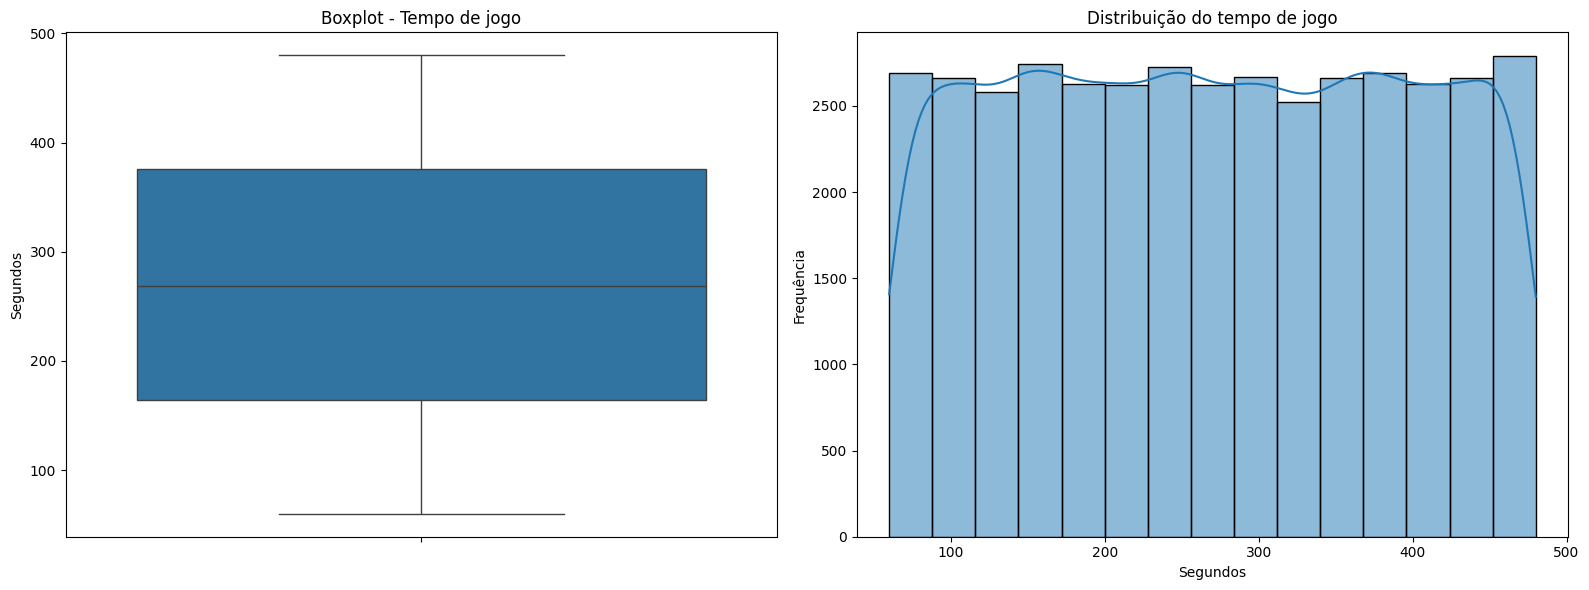

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16,6))

# Boxplot
sns.boxplot(
    y=df["time_to_complete_sec"],
    ax=axes[0]
)

axes[0].set_title("Boxplot - Tempo de jogo")
axes[0].set_ylabel("Segundos")

# Histograma
sns.histplot(
    df["time_to_complete_sec"],
    bins=15,
    kde=True,
    ax=axes[1]
)

axes[1].set_title("Distribuição do tempo de jogo")
axes[1].set_xlabel("Segundos")
axes[1].set_ylabel("Frequência")

plt.tight_layout()
plt.show()

In [64]:
df['time_to_complete_sec'].quantile([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])

,time_to_complete_sec
0.1,101.0
0.2,144.0
0.3,185.0
0.4,228.0
0.5,269.0
0.6,311.8
0.7,355.0
0.8,396.0
0.9,439.0
1.0,480.0


O tempo de conclusão das partidas apresentou distribuição uniforme, com valores distribuídos de forma aproximadamente igual ao longo de toda a faixa observada e mediana de 269 segundos (aproximadamente 4,5 minutos). Observa-se que 80% das sessões foram concluídas em até 396 segundos (cerca de 6,6 minutos), indicando que o Palavritas é uma atividade de curta duração. Nesta etapa, o objetivo é apenas compreender a distribuição da variável, uma vez que sua relação com a retenção será investigada posteriormente.

### 4.3 Variáveis discretas

In [65]:
vars_discretas = [
    "attempts",
    "session_hour",
    "streak_day",
    "food_delivery_freq_week"
]

for var in vars_discretas:

    print(f"\n{'='*80}")
    print(var.upper())
    print('='*80)

    tabela = (
        df[var]
        .value_counts(dropna=True)
        .sort_index()
        .to_frame("Frequência")
    )

    tabela["Percentual (%)"] = round(
        tabela["Frequência"] / tabela["Frequência"].sum() * 100,
        2
    )

    tabela["Frequência Acumulada"] = tabela["Frequência"].cumsum()

    tabela["Percentual Acumulado (%)"] = round(
        tabela["Frequência Acumulada"] / tabela["Frequência"].sum() * 100,
        2
    )

    tabela["Retenção D+1 (%)"] = (
        df.groupby(var)["played_next_day"]
        .mean()
        .mul(100)
        .round(2)
    )

    tabela["Active D30 (%)"] = (
        df.groupby(var)["active_d30"]
        .mean()
        .mul(100)
        .round(2)
    )

    display(tabela)


ATTEMPTS


,Frequência,Percentual (%),Frequência Acumulada,Percentual Acumulado (%),Retenção D+1 (%),Active D30 (%)
attempts,,,,,,
1,8065,20.23,8065,20.23,21.60,32.91
2,8043,20.17,16108,40.40,21.83,32.64
3,7950,19.94,24058,60.34,22.30,32.43
6,15811,39.66,39869,100.00,22.49,30.84



SESSION_HOUR


,Frequência,Percentual (%),Frequência Acumulada,Percentual Acumulado (%),Retenção D+1 (%),Active D30 (%)
session_hour,,,,,,
6,4146,10.40,4146,10.40,21.15,36.35
7,4255,10.67,8401,21.07,22.87,38.47
8,4161,10.44,12562,31.51,21.94,37.83
12,1388,3.48,13950,34.99,21.47,27.38
13,1401,3.51,15351,38.50,22.77,29.12
14,1386,3.48,16737,41.98,23.88,27.99
15,1412,3.54,18149,45.52,24.72,34.28
16,1350,3.39,19499,48.91,20.00,28.81
17,1373,3.44,20872,52.35,22.65,31.03



STREAK_DAY


,Frequência,Percentual (%),Frequência Acumulada,Percentual Acumulado (%),Retenção D+1 (%),Active D30 (%)
streak_day,,,,,,
1,31050,77.88,31050,77.88,21.67,31.95
2,6722,16.86,37772,94.74,23.45,31.82
3,1576,3.95,39348,98.69,23.79,31.41
4,374,0.94,39722,99.63,27.54,33.96
5,104,0.26,39826,99.89,29.81,35.58
6,31,0.08,39857,99.97,29.03,35.48
7,9,0.02,39866,99.99,33.33,33.33
8,3,0.01,39869,100.00,0.00,0.00



FOOD_DELIVERY_FREQ_WEEK


,Frequência,Percentual (%),Frequência Acumulada,Percentual Acumulado (%),Retenção D+1 (%),Active D30 (%)
food_delivery_freq_week,,,,,,
0.0,3638,13.62,3638,13.62,20.59,32.19
1.0,5237,19.61,8875,33.24,22.86,32.75
2.0,6828,25.57,15703,58.81,22.66,31.75
3.0,5390,20.18,21093,78.99,21.86,31.80
5.0,3319,12.43,24412,91.42,22.30,32.30
7.0,2291,8.58,26703,100.00,24.05,33.30


A maior parte das sessões utilizou uma, duas ou três tentativas, enquanto cerca de 40% chegaram ao limite de seis tentativas. As taxas de retenção apresentaram pouca variação entre as categorias. Observou-se uma tendência de maior retenção no dia seguinte conforme aumenta o streak_day e de maior permanência em 30 dias entre usuários que jogam pela manhã. Entre os usuários que responderam à pesquisa, a frequência de pedidos por delivery não apresentou diferenças relevantes nesta análise descritiva.

### 4.4 Variáveis categóricas e de perfil do Usuário



In [66]:
tabela = (
    df.groupby("newsletter_open_before_game")
      .agg(
          sessoes=("session_id","count"),
          retencao_d1=("played_next_day","mean"),
          active_d30=("active_d30","mean")
      )
)

tabela["retencao_d1"] = (tabela["retencao_d1"]*100).round(2)
tabela["active_d30"] = (tabela["active_d30"]*100).round(2)

display(tabela)

,sessoes,retencao_d1,active_d30
newsletter_open_before_game,,,
False,32214,22.29,30.54
True,7655,21.53,37.81


In [67]:
tabela = (
    df.groupby("word")
      .agg(
          sessoes=("session_id","count"),
          tentativas=("attempts","mean"),
          tempo=("time_to_complete_sec","mean"),
          retencao_d1=("played_next_day","mean"),
          active_d30=("active_d30","mean")
      )
      .sort_values("retencao_d1", ascending=False)
)

tabela["tentativas"] = tabela["tentativas"].round(2)
tabela["tempo"] = tabela["tempo"].round(0)
tabela["retencao_d1"] = (tabela["retencao_d1"]*100).round(2)
tabela["active_d30"] = (tabela["active_d30"]*100).round(2)

display(tabela)

,sessoes,tentativas,tempo,retencao_d1,active_d30
word,,,,,
PRETO,875,3.35,265.0,24.69,31.77
JOGOS,880,3.50,273.0,24.32,32.16
PAZÃO,1766,4.20,271.0,23.95,32.84
TROCO,879,3.36,267.0,23.66,28.56
NIXÃO,906,4.13,268.0,23.62,33.77
PRAIA,870,3.38,274.0,23.56,31.15
GENRO,897,3.31,261.0,23.52,33.89
IDEIA,873,3.37,261.0,23.25,32.88
CIÚME,912,4.23,267.0,23.25,33.00


A análise por palavra não revelou padrão claro entre dificuldade e retenção. Palavras como PRETO e JOGOS, com médias de tentativas mais baixas, aparecem no topo da retenção D+1, enquanto FRACO e NUVEM, com perfis similares, figuram entre as menores taxas.

In [68]:
tabela = (
    df.groupby("device")
      .agg(
          sessoes=("session_id","count"),
          retencao_d1=("played_next_day","mean"),
          active_d30=("active_d30","mean")
      )
)

tabela["retencao_d1"] = (tabela["retencao_d1"]*100).round(2)
tabela["active_d30"] = (tabela["active_d30"]*100).round(2)

display(tabela)

,sessoes,retencao_d1,active_d30
device,,,
android,18122,21.97,31.82
ios,21747,22.28,32.04


In [69]:
perfil = [
    "age_range",
    "state",
    "salary_range",
    "sector",
    "job_role",
    "company_size",
    "primary_device",
    "plays_other_word_games",
    "newsletter_subscriber",
    "typical_play_time",
    "orders_food_delivery",
    "food_delivery_platform"
]

for var in perfil:

    tabela = (
        df.groupby(var)
          .agg(
              sessoes=("session_id","count"),
              quantidade=("user_id","nunique"),
              retencao_d1=("played_next_day","mean"),
              active_d30=("active_d30","mean")
          )
    )

    tabela["retencao_d1"] = (tabela["retencao_d1"]*100).round(2)
    tabela["active_d30"] = (tabela["active_d30"]*100).round(2)

    print("\n"+"="*70)
    print(var.upper())
    print("="*70)

    display(tabela)


AGE_RANGE


,sessoes,quantidade,retencao_d1,active_d30
age_range,,,,
18-24,3223,101,21.84,32.21
25-34,9647,284,22.56,32.17
35-44,6636,203,21.61,32.34
45+,3268,95,23.87,32.65
Não informado,3929,117,22.09,31.79



STATE


,sessoes,quantidade,retencao_d1,active_d30
state,,,,
AL,1585,47,23.28,32.81
AM,1610,45,23.17,31.12
BA,1177,36,21.84,31.69
CE,953,29,22.25,32.84
DF,1358,40,21.50,33.06
ES,1542,43,24.06,31.84
GO,1307,45,21.42,29.99
MA,1445,45,19.45,31.97
MG,1801,58,20.66,30.59



SALARY_RANGE


...

,sessoes,quantidade,retencao_d1,active_d30
typical_play_time,,,,
afternoon,5707,164,23.20,30.44
evening,7217,220,21.55,29.00
morning,8540,256,22.75,37.80
night,5239,160,21.76,29.49



ORDERS_FOOD_DELIVERY


,sessoes,quantidade,retencao_d1,active_d30
orders_food_delivery,,,,
False,3638,115,20.59,32.19
True,23065,685,22.60,32.22



FOOD_DELIVERY_PLATFORM


,sessoes,quantidade,retencao_d1,active_d30
food_delivery_platform,,,,
Ambos,5600,164,23.41,33.11
Nenhum,9238,283,21.53,32.42
Rappi,6045,180,22.02,31.17
iFood,5820,173,22.87,32.13


In [70]:
df["time_category"] = pd.cut(
    df["time_to_complete_sec"],
    bins=[0, 120, 240, 360, 480],
    labels=["até 2min", "2-4min", "4-6min", "6min+"]
)

In [71]:
perfil = [
    "result",
    "time_category"
]

for var in perfil:

    tabela = (
        df.groupby(var)
          .agg(
              sessoes=("session_id","count"),
              quantidade=("user_id","nunique"),
              retencao_d1=("played_next_day","mean"),
              active_d30=("active_d30","mean")
          )
    )

    tabela["retencao_d1"] = (tabela["retencao_d1"]*100).round(2)
    tabela["active_d30"] = (tabela["active_d30"]*100).round(2)

    print("\n"+"="*70)
    print(var.upper())
    print("="*70)

    display(tabela)


RESULT


,sessoes,quantidade,retencao_d1,active_d30
result,,,,
lose,15811,1190,22.49,30.84
win,24043,1200,21.91,32.66



TIME_CATEGORY


/tmp/ipykernel_2628/1548903821.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(var)


,sessoes,quantidade,retencao_d1,active_d30
time_category,,,,
até 2min,5806,1134,21.99,31.93
2-4min,11354,1188,21.60,31.39
4-6min,11268,1194,22.61,32.63
6min+,11441,1187,22.29,31.80


In [72]:
regioes = {
    'AC': 'Norte', 'AM': 'Norte', 'AP': 'Norte', 'PA': 'Norte', 'RO': 'Norte', 'RR': 'Norte', 'TO': 'Norte',
    'AL': 'Nordeste', 'BA': 'Nordeste', 'CE': 'Nordeste', 'MA': 'Nordeste', 'PB': 'Nordeste',
    'PE': 'Nordeste', 'PI': 'Nordeste', 'RN': 'Nordeste', 'SE': 'Nordeste',
    'DF': 'Centro-Oeste', 'GO': 'Centro-Oeste', 'MS': 'Centro-Oeste', 'MT': 'Centro-Oeste',
    'ES': 'Sudeste', 'MG': 'Sudeste', 'RJ': 'Sudeste', 'SP': 'Sudeste',
    'PR': 'Sul', 'RS': 'Sul', 'SC': 'Sul'
}
df["regiao"] = df["state"].map(regioes)


def agrupar_cargo(cargo):
    if pd.isna(cargo):
        return cargo
    cargo = cargo.lower()
    categorias = ["analista", "coordenador", "desenvolvedor", "designer",
                  "diretor", "engenheiro", "estudante", "gerente",
                  "professor", "consultor"]
    for cat in categorias:
        if cat in cargo:
            if "dados" in cargo:
                return "dados"
            return cat
    return "outros"

df["cargo_grupo"] = df["job_role"].apply(agrupar_cargo)


df["streak_cat"] = pd.cut(
    df["streak_day"],
    bins=[0, 1, 3, 7],
    labels=["1 dia", "2-3 dias", "4-7 dias"]
)

df["win"] = (df["result"] == "win").astype(int)

In [73]:
perfil = [
    "regiao",
    "cargo_grupo",
    "streak_cat"
]

for var in perfil:

    tabela = (
        df.groupby(var)
          .agg(
              sessoes=("session_id","count"),
              quantidade=("user_id","nunique"),
              retencao_d1=("played_next_day","mean"),
              active_d30=("active_d30","mean")
          )
    )

    tabela["retencao_d1"] = (tabela["retencao_d1"]*100).round(2)
    tabela["active_d30"] = (tabela["active_d30"]*100).round(2)

    print("\n"+"="*70)
    print(var.upper())
    print("="*70)

    display(tabela)


REGIAO


,sessoes,quantidade,retencao_d1,active_d30
regiao,,,,
Centro-Oeste,4945,155,21.74,31.57
Nordeste,9862,301,21.54,32.02
Norte,1610,45,23.17,31.12
Sudeste,6184,181,22.95,32.18
Sul,4102,118,23.67,33.96



CARGO_GRUPO


,sessoes,quantidade,retencao_d1,active_d30
cargo_grupo,,,,
analista,2768,81,22.40,31.61
consultor,2363,66,22.89,33.60
coordenador,2851,82,25.25,34.76
dados,1725,51,22.61,32.17
desenvolvedor,1669,55,20.61,30.62
designer,2153,70,21.23,30.42
diretor,3358,94,22.54,33.14
engenheiro,2240,69,20.85,33.30
estudante,2467,72,22.78,30.00



STREAK_CAT


/tmp/ipykernel_2628/888952509.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(var)


,sessoes,quantidade,retencao_d1,active_d30
streak_cat,,,,
1 dia,31050,1200,21.67,31.95
2-3 dias,8298,1054,23.51,31.74
4-7 dias,518,282,28.19,34.36


### 4.5 Principais achados da análise exploratória

- A taxa de retorno no dia seguinte permaneceu relativamente estável entre os diferentes números de tentativas e frequências de pedidos por delivery, sem indícios visuais de associação relevante.
- Usuários que jogam pela manhã apresentaram maior proporção de permanência após 30 dias. Uma hipótese é que esse comportamento esteja relacionado ao consumo da newsletter, enviada no início da manhã, aumentando o engajamento com o Palavritas.
- O aumento do streak_day foi acompanhado por uma elevação gradual da retenção no dia seguinte, sugerindo que a formação do hábito pode ser um dos principais fatores associados ao retorno dos usuários.
- Entre os usuários que responderam à pesquisa, observou-se maior permanência em D30 em alguns segmentos específicos, como usuários com **45 anos ou mais**, residentes no **Rio Grande do Sul e Rio de Janeiro**, profissionais do **setor de educação** e ocupantes de **cargos de coordenação**. Como essas informações estão disponíveis apenas para os respondentes da pesquisa, esses achados devem ser tratados como hipóteses para validação.

Em conjunto, os resultados da EDA indicam que **horário de jogo, abertura da newsletter, sequência de dias (streak) e algumas características do perfil do usuário** merecem investigação mais aprofundada nas próximas etapas da análise.

Hipóteses:

- Usuários que abrem a newsletter antes de jogar apresentam maior retenção em D30 porque a newsletter funciona como um gatilho diário para iniciar a sessão no Palavritas?
- Usuários que jogam pela manhã apresentam maior retenção em D30 porque esse comportamento está associado ao consumo da newsletter enviada às 6h06?
- A mecânica de streak incentiva a formação de hábito, aumentando a probabilidade de retorno no dia seguinte?


A evolução temporal dos indicadores mostrou estabilidade ao longo do período analisado, sem evidências visuais de tendência ou sazonalidade que justificassem análises específicas por data.

## 4.6 Relação entre os indicadores de retenção

In [74]:
print(df[["played_next_day", "active_d30"]].corr())


pd.crosstab(
    df["played_next_day"],
    df["active_d30"],
    normalize="index"
) * 100

                 played_next_day  active_d30
played_next_day         1.000000    0.399593
active_d30              0.399593    1.000000


active_d30,False,True
played_next_day,,
False,77.997552,22.002448
True,33.125637,66.874363


Há uma associação moderada entre o retorno no dia seguinte e a permanência em 30 dias (φ = 0,40). Entre os usuários que retornaram no dia seguinte, 66,9% permaneceram ativos após 30 dias, enquanto entre aqueles que não retornaram essa proporção foi de 22,0%. Embora essa análise não permita estabelecer causalidade, ela indica que iniciativas voltadas ao aumento da retenção imediata podem contribuir para melhorar também a retenção de longo prazo

# 5. Significância Estatística dos Achados

In [75]:
from scipy.stats import chi2_contingency
import numpy as np

def testar_associacao(df, feature, target):

    tabela = pd.crosstab(df[feature], df[target])

    chi2, p, _, _ = chi2_contingency(tabela)

    n = tabela.values.sum()
    r, c = tabela.shape

    cramer_v = np.sqrt(
        chi2 /
        (n * (min(r - 1, c - 1)))
    )

    return pd.Series({
        "Qui2": round(chi2,2),
        "p_valor": round(p,5),
        "Cramers_V": round(cramer_v,3)
    })

In [76]:
variaveis = [
    col for col in df.columns
    if col not in [
        "session_id",
        "user_id",
        "word_date",
        "played_next_day",
        "active_d30",
        "job_role",
        "city",
        "time_to_complete_sec",
        "word"
    ]
]

In [77]:
resultado = []

for var in variaveis:

    try:

        resultado.append({
            "variavel": var,
            **testar_associacao(df, var, "played_next_day")
        })

    except:
        pass

resultado_d1 = (
    pd.DataFrame(resultado)
    .sort_values("Cramers_V", ascending=False)
)

resultado_d1

,variavel,Qui2,p_valor,Cramers_V
7,state,41.50,0.00207,0.039
20,cargo_grupo,30.42,0.00073,0.034
3,session_hour,26.20,0.02443,0.026
4,streak_day,25.28,0.00068,0.025
21,streak_cat,23.94,0.00001,0.025
9,sector,12.10,0.09738,0.021
12,food_delivery_freq_week,12.24,0.03170,0.021
19,regiao,10.83,0.02852,0.020
13,food_delivery_platform,8.49,0.03689,0.018
6,age_range,7.30,0.12101,0.017


In [78]:
resultado = []

for var in variaveis:

    try:

        resultado.append({
            "variavel": var,
            **testar_associacao(df, var, "active_d30")
        })

    except:
        pass

resultado_d30 = (
    pd.DataFrame(resultado)
    .sort_values("Cramers_V", ascending=False)
)

resultado_d30

,variavel,Qui2,p_valor,Cramers_V
3,session_hour,302.07,0.00000,0.087
16,typical_play_time,182.14,0.00000,0.083
5,newsletter_open_before_game,149.76,0.00000,0.061
7,state,26.29,0.12231,0.031
20,cargo_grupo,26.04,0.00369,0.031
1,result,14.50,0.00014,0.019
0,attempts,14.95,0.00186,0.019
22,win,14.57,0.00013,0.019
19,regiao,7.72,0.10228,0.017
9,sector,7.80,0.35020,0.017


Nenhuma variável isoladamente apresentou forte associação com a retenção. Entretanto, a análise exploratória e os testes estatísticos convergem ao indicar que fatores comportamentais, especialmente **horário de jogo, consumo da newsletter e formação de hábito (streak)**, são os principais candidatos para orientar experimentos de produto.

Para complementar a análise exploratória, foi aplicado o teste Qui-quadrado de independência em conjunto com o coeficiente de Cramer's V, com o objetivo de avaliar a força da associação entre as variáveis categóricas e os indicadores de retenção.

Os resultados indicam que nenhuma variável isoladamente apresentou forte associação com o retorno dos usuários, sugerindo que a retenção é influenciada por múltiplos fatores. Ainda assim, observou-se uma associação consistente entre horário de jogo, período típico de uso e abertura da newsletter antes da partida com a permanência em 30 dias.

Para o retorno no dia seguinte, as associações foram ainda menores, destacando-se principalmente a sequência de dias (streak) e o horário de jogo. Esses resultados reforçam a hipótese de que fatores comportamentais possuem maior potencial para explicar a retenção do que características demográficas do usuário.

# 6. Propostas

Nenhuma variável isoladamente explica a retenção dos usuários. Entretanto, a convergência entre a análise exploratória e os testes estatísticos indica que fatores comportamentais, especialmente o horário de jogo, a interação com a newsletter e a formação do hábito (streak), apresentam as evidências mais consistentes para orientar experimentos de Produto. Esse resultado sugere que ganhos de retenção provavelmente serão obtidos por meio da combinação de pequenas melhorias na experiência do usuário, e não pela atuação sobre um único fator isolado. Assim, as recomendações deste trabalho priorizam intervenções sobre o comportamento do usuário, em vez de segmentações demográficas.

## Proposta 1
### Hipótese

Usuários que jogam logo após consumir a newsletter desenvolvem um hábito diário mais forte, aumentando a retenção de longo prazo.

### Ação

Sincronizar a disponibilização do novo desafio com o horário de envio da newsletter e destacar o CTA do Palavritas na newsletter.

###Critério de sucesso
- aumento do Played Next Day
- aumento do Active D30
- aumento da taxa de acesso ao Palavritas a partir da newsletter
<br>

## Proposta 2
### Hipótese

O mecanismo de sequência de dias incentiva a formação do hábito e aumenta a probabilidade de retorno no dia seguinte. Isso pode ser potencializado por recompensas progressivas, aumentando a motivação para manter a sequência de jogos.

### Ação

Testar um sistema de recompensas por marcos de streak, oferecendo benefícios progressivos dentro do ecossistema do the news como badges, funcionalidades exclusivas do aplicativo ou um período gratuito de assinatura após atingir um determinado marco de dias consecutivos.

### Critério de sucesso
- aumento do Played Next Day;
- aumento do streak médio dos usuários;
- aumento do Active D30 em relação ao grupo controle nas semanas seguintes.
<br>

## Proposta 3
### Hipótese

O retorno no dia seguinte representa um comportamento precursor da retenção de longo prazo. Se conseguirmos aumentar o D+1 (jogar no dia seguinte), parte desse ganho poderá refletir na permanência após 30 dias.

### Ação

Enviar notificações push apenas para usuários que ainda não iniciaram a partida do dia, respeitando o horário em que cada usuário costuma jogar (por exemplo, manhã, almoço ou noite), incentivando o retorno antes do encerramento do desafio.

### Critério de sucesso

- aumento da taxa de Played Next Day no grupo tratado em relação ao grupo controle;
- acompanhamento do impacto desse grupo sobre o Active D30 nas semanas seguintes.



In [79]:
sessions_clean.to_csv('sessions_clean.csv', sep=',', index=False)
attempts_clean.to_csv('attempts_clean.csv', sep=',', index=False)
users_clean.to_csv('users_clean.csv', sep=',', index=False)